In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import random
import time

from src.generator import BasicPerturbationGenerator, AdvancedPerturbationGenerator
from src.nn import CNNModel, MLPModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training with: {device}")

🚀 Training with: cuda


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"🔒 Llavor aleatòria fixada a {SEED}. L'experiment ara és 100% reproduïble.")

🔒 Llavor aleatòria fixada a 42. L'experiment ara és 100% reproduïble.


In [3]:
# Transformacions per a CIFAR-10 (Ara són 3 canals RGB i normalitzem)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

# CIFAR-10 dataset: 50,000 imatges d'entrenament i 10,000 de test.
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# Definim les classes per quan fem els gràfics
classes = ('avió', 'cotxe', 'ocell', 'gat', 'cérvol', 'gos', 'granota', 'cavall', 'vaixell', 'camió')

print(f"📦 Imatges d'entrenament: {len(trainset)}")
print(f"📦 Imatges de test: {len(testset)}")

Files already downloaded and verified


c:\Users\win11\Documents\Guillem\TFG\Adversarial-Attacks-on-Neural-Networks-A-Game-Theory-Approach\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
📦 Imatges d'entrenament: 50000
📦 Imatges de test: 10000


In [4]:
# MODELS configurats per a CIFAR-10 (3 canals RGB, 32x32)
classifier = CNNModel(in_channels=3, input_size=32).to(device)
generator = AdvancedPerturbationGenerator(in_channels=3).to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizadors
optimizer_C = torch.optim.Adam(classifier.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.001)

# Epsilon per a l'atac (el baixem moltíssim perquè a CIFAR-10 el soroll s'amaga millor)
epsilon = 0.1

In [5]:
print("🛡️ Iniciant FASE 1: Pre-entrenament del Defensor...")
epochs_pretrain = 5
classifier.train()

start_time = time.time()

for epoch in range(epochs_pretrain):
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer_C.zero_grad()
        outputs = classifier(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer_C.step()
        
        running_loss += loss.item()
        
    print(f"Època {epoch+1}/{epochs_pretrain} completada. Loss Neta: {running_loss/len(trainloader):.4f}")

print(f"✅ FASE 1 Completada en {time.time() - start_time:.2f} segons. La CNN ja és capaç de classificar.")

🛡️ Iniciant FASE 1: Pre-entrenament del Defensor...
Època 1/5 completada. Loss Neta: 1.6951
Època 2/5 completada. Loss Neta: 1.4704
Època 3/5 completada. Loss Neta: 1.3751
Època 4/5 completada. Loss Neta: 1.3151
Època 5/5 completada. Loss Neta: 1.2752
✅ FASE 1 Completada en 129.59 segons. La CNN ja és capaç de classificar.


In [6]:
print("🔍 Avaluant l'Accuracy del Defensor després del pre-entrenament (FASE 1)...")

# 1. Posem el model en mode avaluació (desactiva coses com el Dropout si en tingués)
classifier.eval()

correct = 0
total = 0

# 2. Desactivem el càlcul de gradients perquè no estem entrenant (estalvia memòria i va més ràpid)
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        
        # Passem les imatges netes per la CNN
        outputs = classifier(images)
        
        # Agafem la classe amb la probabilitat més alta
        _, predicted = torch.max(outputs.data, 1)
        
        # Sumem quantes imatges hi ha al batch i quantes hem encertat
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# 3. Calculem el percentatge d'encert
accuracy_clean = 100 * correct / total

print(f"🎯 Accuracy del Defensor en imatges NETES: {accuracy_clean:.2f}%")
print("Aquest és el 'Baseline'. A veure què passa quan el Generador comenci a atacar!")

🔍 Avaluant l'Accuracy del Defensor després del pre-entrenament (FASE 1)...
🎯 Accuracy del Defensor en imatges NETES: 61.62%
Aquest és el 'Baseline'. A veure què passa quan el Generador comenci a atacar!


In [7]:
print("⚔️ Iniciant FASE 2: Combat Minimax (Micro-Optimització)...")
max_combat_epochs = 5 # Pots pujar-ho a 10 per veure més l'efecte

start_time = time.time()

for epoch in range(max_combat_epochs):
    running_loss_C = 0.0
    running_loss_G = 0.0
    
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        
        # ============================================
        # TORN 1: JUGADA DE L'ATACANT (Generador)
        # ============================================
        # 1. CONGELEM EL DEFENSOR: Posem la CNN en mode avaluació 
        # perquè no actualitzi els seus propis paràmetres ni el BatchNorm
        classifier.eval() 
        generator.train()
        
        for _ in range(2):
            optimizer_G.zero_grad()
            
            x_adv, delta = generator(images, epsilon=epsilon)
            outputs_adv = classifier(x_adv)
            
            # 2. INVERTIM LA PÈRDUA (Atac no dirigit):
            # Calculem l'error sobre la classe REAL i el multipliquem per -1.
            # En minimitzar aquesta loss_G, PyTorch en realitat estarà MAXIMITZANT
            # l'error de la CNN.
            loss_cnn = criterion(outputs_adv, labels)
            loss_G = -loss_cnn 
            
            loss_G.backward()
            optimizer_G.step()
            
            running_loss_G += loss_G.item()
            
        # ============================================
        # TORN 2: JUGADA DEL DEFENSOR (Classificador)
        # ============================================
        # 3. DESCONGELEM EL DEFENSOR: Torna a estar en mode entrenament
        classifier.train() 
        generator.eval()
        
        optimizer_C.zero_grad()
        
        # Avaluem com ho fa amb la imatge ORIGINAL (Neta)
        outputs_clean = classifier(images)
        loss_C_clean = criterion(outputs_clean, labels)

        # Avaluem com ho fa amb la imatge ATACADA (Bruta)
        # Generem l'atac un cop més amb el generador actualitzat
        x_adv, _ = generator(images, epsilon=epsilon) 
        x_adv_final = x_adv.detach() # Detach perquè els gradients no vagin al generador
        outputs_def = classifier(x_adv_final)
        loss_C_adv = criterion(outputs_def, labels)
        
        # La pèrdua total del Defensor
        loss_C = (loss_C_clean + loss_C_adv) / 2
        
        loss_C.backward()
        optimizer_C.step()
        
        running_loss_C += loss_C.item()
        
    # Mitjanes per època
    avg_loss_C = running_loss_C / len(trainloader)
    avg_loss_G = (running_loss_G / 2) / len(trainloader)
    
    print(f"Combat Època {epoch+1}/{max_combat_epochs} | Loss Defensor: {avg_loss_C:.4f} | Loss Atacant: {avg_loss_G:.4f}")

print(f"🏁 Joc finalitzat en {time.time() - start_time:.2f} segons.")

⚔️ Iniciant FASE 2: Combat Minimax (Micro-Optimització)...
Combat Època 1/5 | Loss Defensor: 1.2983 | Loss Atacant: -1.0994
Combat Època 2/5 | Loss Defensor: 1.2905 | Loss Atacant: -1.1260
Combat Època 3/5 | Loss Defensor: 1.2786 | Loss Atacant: -1.1325
Combat Època 4/5 | Loss Defensor: 1.2511 | Loss Atacant: -1.1018
Combat Època 5/5 | Loss Defensor: 1.2343 | Loss Atacant: -1.0809
🏁 Joc finalitzat en 375.40 segons.


In [8]:
# Mode avaluació per apagar el Dropout i congelar el BatchNorm
classifier.eval()
generator.eval()

correct_clean = 0
correct_adv = 0
total = 0

print("🔍 Avaluant el resultat del joc amb les dades de Test (10.000 imatges)...")

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        
        # 1. El Defensor juga sol (Classificació Neta)
        outputs_clean = classifier(images)
        _, predicted_clean = torch.max(outputs_clean.data, 1)
        correct_clean += (predicted_clean == labels).sum().item()
        
        # 2. El Defensor juga contra l'Atacant (Classificació sota Atac)
        x_adv, _ = generator(images, epsilon=epsilon)
        outputs_adv = classifier(x_adv)
        _, predicted_adv = torch.max(outputs_adv.data, 1)
        correct_adv += (predicted_adv == labels).sum().item()
        
        total += labels.size(0)

acc_clean = 100 * correct_clean / total
acc_adv = 100 * correct_adv / total

print("-" * 55)
print(f"📊 RESULTATS ESTRATÈGICS FINALS (MACRO-JOC):")
print(f"🛡️ Utilitat del Defensor en pau (Acc Neta):    {acc_clean:.2f}%")
print(f"⚔️ Utilitat del Defensor en guerra (Acc Adv):   {acc_adv:.2f}%")
print(f"🎯 Utilitat de l'Atacant (Drop en Acc):         -{acc_clean - acc_adv:.2f} punts")
print("-" * 55)

🔍 Avaluant el resultat del joc amb les dades de Test (10.000 imatges)...
-------------------------------------------------------
📊 RESULTATS ESTRATÈGICS FINALS (MACRO-JOC):
🛡️ Utilitat del Defensor en pau (Acc Neta):    63.54%
⚔️ Utilitat del Defensor en guerra (Acc Adv):   58.34%
🎯 Utilitat de l'Atacant (Drop en Acc):         -5.20 punts
-------------------------------------------------------


C:\Users\win11\AppData\Local\Temp\ipykernel_20828\1741838565.py:69: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\win11\AppData\Local\Temp\ipykernel_20828\1741838565.py:70: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.savefig("visualitzacio_combat.png")
c:\Users\win11\Documents\Guillem\TFG\Adversarial-Attacks-on-Neural-Networks-A-Game-Theory-Approach\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


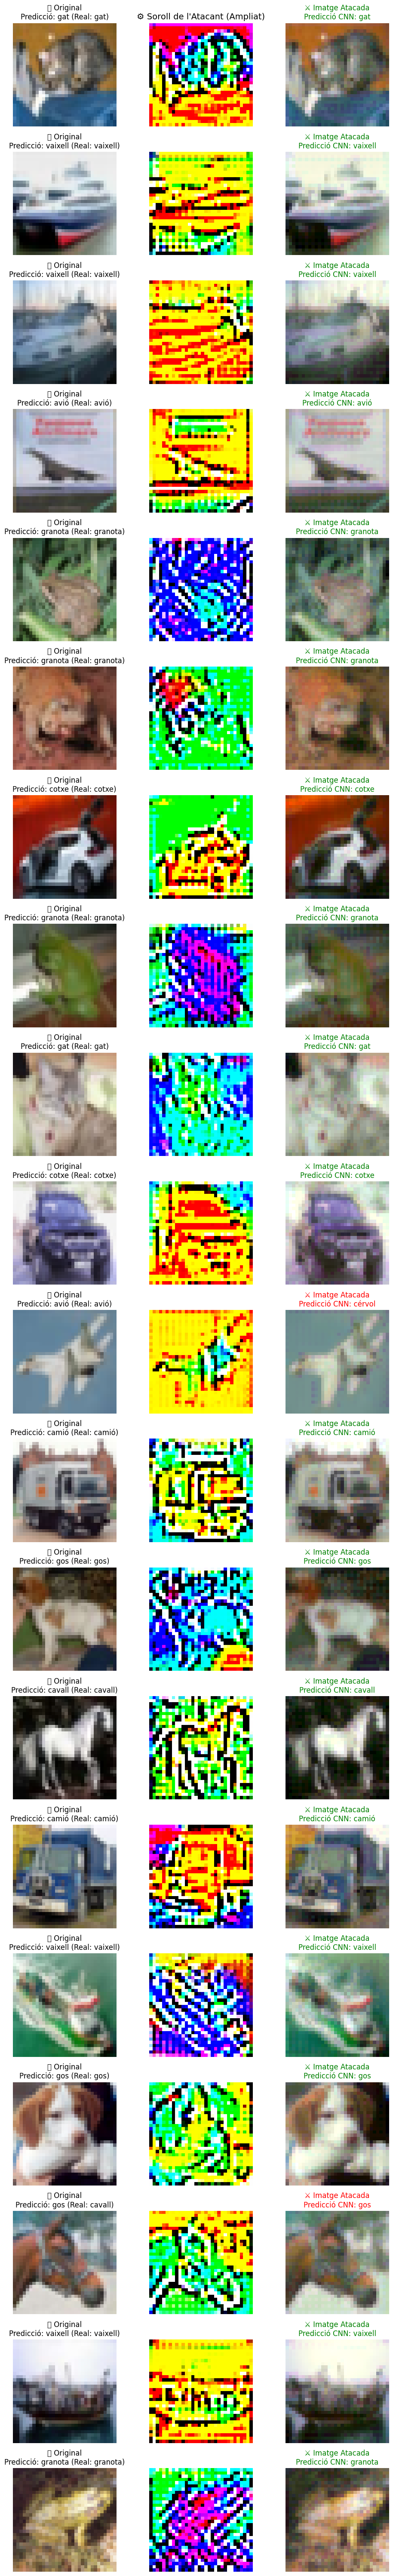

In [9]:
# Llista de classes per posar el nom en lloc del número
classes = ('avió', 'cotxe', 'ocell', 'gat', 'cérvol', 'gos', 'granota', 'cavall', 'vaixell', 'camió')

# Funció per des-normalitzar imatges i preparar-les per Matplotlib
def format_img(tensor):
    img = tensor.cpu().numpy()
    img = img / 2 + 0.5                 # 1. Des-normalitzem de [-1, 1] a [0, 1]
    img = np.transpose(img, (1, 2, 0))  # 2. PyTorch (C, H, W) -> Matplotlib (H, W, C)
    return np.clip(img, 0, 1)           # 3. Assegurem que cap píxel surti de [0, 1]

# Funció per fer el soroll (que són valors molt petits i negatius) visible
def format_noise(tensor):
    noise = tensor.cpu().numpy()
    noise = np.transpose(noise, (1, 2, 0))
    # Escalem el soroll perquè el puguem veure bé (de [min, max] a [0, 1])
    n_min, n_max = noise.min(), noise.max()
    if n_max - n_min > 1e-6:
        noise = (noise - n_min) / (n_max - n_min)
    return np.clip(noise, 0, 1)

# Definim quantes imatges del batch volem visualitzar
num_images = 20  # Ho poso a 10 perquè es vegi bé sense fer un gràfic infinit

# Agafem un sol batch per fer la visualització
images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

# Generem l'atac i fem les prediccions
with torch.no_grad():
    x_adv, noise = generator(images, epsilon=epsilon)
    
    outputs_clean = classifier(images)
    _, pred_clean = torch.max(outputs_clean, 1)
    
    outputs_adv = classifier(x_adv)
    _, pred_adv = torch.max(outputs_adv, 1)

# Creem el gràfic
fig, axes = plt.subplots(num_images, 3, figsize=(10, 3 * num_images))

for idx in range(num_images):
    # Processem els tensors cap a imatges RGB usant les nostres funcions
    img_clean = format_img(images[idx])
    img_noise = format_noise(noise[idx])
    img_adv = format_img(x_adv[idx])

    # Traduïm els números a paraules
    label_true = classes[labels[idx].item()]
    label_clean = classes[pred_clean[idx].item()]
    label_adv = classes[pred_adv[idx].item()]

    # -- Columna 0: Imatge Original --
    axes[idx, 0].imshow(img_clean) # Ja no cal cmap='gray' perquè ara és RGB
    axes[idx, 0].set_title(f"🛡️ Original\nPredicció: {label_clean} (Real: {label_true})", fontsize=12)
    axes[idx, 0].axis('off')

    # -- Columna 1: El Soroll de l'Atacant --
    axes[idx, 1].imshow(img_noise)
    if idx == 0:
        axes[idx, 1].set_title("⚙️ Soroll de l'Atacant (Ampliat)", fontsize=14)
    axes[idx, 1].axis('off')

    # -- Columna 2: Imatge Enganyada --
    axes[idx, 2].imshow(img_adv)
    color = 'green' if label_adv == label_true else 'red'
    axes[idx, 2].set_title(f"⚔️ Imatge Atacada\nPredicció CNN: {label_adv}", fontsize=12, color=color)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.savefig("visualitzacio_combat.png")
plt.show()